# Clustering Evaluation

In [1]:
import pandas as pd
import json
from sklearn.feature_extraction import DictVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import MiniBatchKMeans
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
import numpy as np
import joblib
import matplotlib.pyplot as plt
# import ast
from collections import defaultdict

## Load and Parse Data

In [2]:
def json_to_dict(obj):
    return json.loads(obj)

def load_csv(path):
    df = pd.read_csv(path, dtype={'username':str})
    df['counts'] = df['counts'].map(json_to_dict)
    return df

In [3]:
df = load_csv(r'count_data\all_batches_sub_posts_count.csv')

In [15]:
df.shape

(218818, 3)

## Vectorizing

In [5]:
vec = DictVectorizer(sparse=True)

X_counts = vec.fit_transform(df['counts'].tolist())

X_counts.shape, X_counts.nnz

((218818, 132717), 2674332)

## Normalizing

In [6]:
tfidf = TfidfTransformer(norm='l2', use_idf=True, smooth_idf=True, sublinear_tf=True)

X_tfidf = tfidf.fit_transform(X_counts)

## Singular Value Decompression

In [7]:
svd = TruncatedSVD(n_components=300, random_state=42)

X_reduced = svd.fit_transform(X_tfidf)

X_reduced.shape

(218818, 300)

## Elbow Method

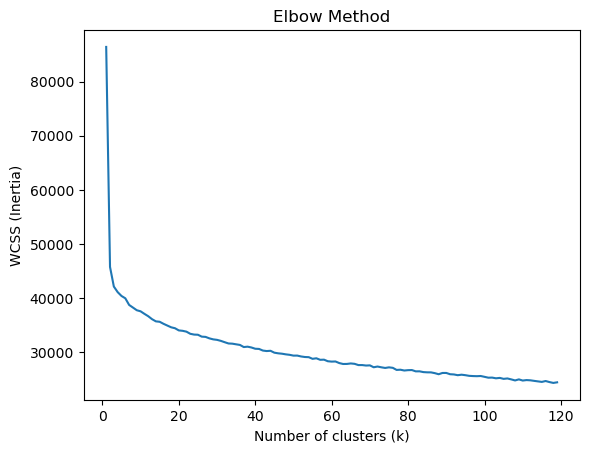

In [9]:
wcss = []
for i in range(1, 120): # Test k from 1 to 10
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_reduced)
    wcss.append(kmeans.inertia_)


plt.plot(range(1, 120), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.show()

## Clustering

In [ ]:
k = 100

kmeans = MiniBatchKMeans(
    n_clusters=k,
    random_state=42,
    batch_size=2000
)

labels=kmeans.fit_predict(X_reduced)
df['clusters'] = labels

c:\Users\vince\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 6144 or by setting the environment variable OMP_NUM_THREADS=8
  warnings.warn(


In [16]:
df.head()

,username,counts,clusters
0,---feelingalone---,{'SuicideWatch': 1},4
1,-anonymously,{'SuicideWatch': 1},4
2,-crave,"{'OopsThatsDeadly': 1, 'tonightsdinner': 2, 'm...",50
3,-dogtopus-,"{'NoStupidQuestions': 1, 'TheGirlSurvivalGuide...",13
4,-ForPrivacy-,{'SuicideWatch': 1},4


In [17]:
df.groupby('clusters').size()

clusters
0       2194
1       2544
2          9
3       2281
4      66942
       ...  
105      892
106     1117
107      446
108      745
109      466
Length: 103, dtype: int64

In [21]:
terms = vec.get_feature_names_out()

def top_subreddits_per_cluster(X_tfidf, labels, top_n=10):
    result = {}
    for c in np.unique(labels):
        idx = np.where(labels == c)[0]
        mean_vec = X_tfidf[idx].mean(axis=0)       # sparse mean
        top_idx = np.asarray(mean_vec.A1).argsort()[-top_n:][::-1]
        result[c] = [terms[i] for i in top_idx]
    return result

cluster_tops = top_subreddits_per_cluster(X_tfidf, labels, top_n=10)
for c in sorted(cluster_tops):
    print(f"Cluster {c}: {', '.join(cluster_tops[c])}")


Cluster 0: depression, SuicideWatch, Anxiety, AskReddit, lonely, socialanxiety, mentalhealth, selfharm, depression_help, ForeverAlone
Cluster 1: relationship_advice, CPTSD, SuicideWatch, OCD, relationships, AskReddit, depression, AmItheAsshole, raisedbynarcissists, mentalhealth
Cluster 2: SuicideWatch, OCD, gaming, mentalillness, antiwork, Showerthoughts, ftm, Music, AskReddit, PetiteFitness
Cluster 3: Philippines, lgbt, GlobalOffensive, tipofmyjoystick, StardewValley, SuicideWatch, traaaaaaannnnnnnnnns, Warframe, ffxiv, Genshin_Impact
Cluster 4: SuicideWatch, zztop, Petscop, PeterboroughUK, PeterboroughUtd, Petercainedestiny, Petgirltraining, Petioles, PetiteAndTiny, PetiteBoobBounce
Cluster 6: askgaybros, whatisthisthing, NameThatSong, MomForAMinute, SuicideWatch, whatsthisbug, conspiracy, amiugly, whatsthisplant, antinatalism
Cluster 8: stopdrinking, SuicideWatch, depression, alcoholism, AskReddit, alcoholicsanonymous, relationship_advice, offmychest, relationships, cripplingalcohol

**Get Counts for Each Cluster Subreddit**

In [ ]:
df.to_csv(r'count_data\all_batches_sub_posts_count_120_clusters.csv', index=False)

### Quick Fix for Messed Up Json Counts*

In [12]:
df = pd.read_csv(r'count_data\all_batches_sub_comments_count.csv')
df2 = pd.read_csv(r'count_data\all_batches_sub_posts_count_120_clusters.csv')

In [13]:
# Add df2 clusters to df
df2 = df2[['username', 'clusters']]
df = df.merge(df2, on='username', how='left')

In [14]:
df.head()

,username,counts,clusters
0,---feelingalone---,"{""SuicideWatch"": 9}",4
1,-anonymously,"{""SuicideWatch"": 7}",4
2,-crave,"{""ElectroBOOM"": 2, ""ImTheMainCharacter"": 1, ""t...",50
3,-dogtopus-,"{""CookingCircleJerk"": 4, ""BestofRedditorUpdate...",13
4,-ForPrivacy-,"{""SuicideWatch"": 7}",4


In [15]:
df.to_csv(r'count_data\all_batches_sub_posts_count_120_clusters.csv')

## Centroid

In [3]:
df = pd.read_csv(r'count_data\all_batches_sub_posts_count_120_clusters.csv')

In [8]:
df['counts'] = df['counts'].apply(json.loads)

In [ ]:
dv = DictVectorizer(sparse=True)

# clusters = df['clusters'].unique()

X = dv.fit_transform(df['counts'])

X = normalize(X, norm="l2", axis=1)


In [ ]:
labels = df['clusters'].to_numpy()

centroids = X.groupby(labels).mean()

avg_users = centroids.to_dict(orient='index')

AttributeError: 'csr_matrix' object has no attribute 'groupby'

## Avg. Cluster Counts

In [ ]:
df = pd.read_csv(r'count_data\all_batches_sub_posts_count_120_clusters.csv')

In [4]:
df['counts'] = df['counts'].apply(json.loads)
clusters = df['clusters'].unique()

In [8]:
clusters

array([  4,  50,  13,   0,  78,  12,  69,  20,  42,  19,  31,   8,  89,
        57,  65,  22,  32,  63, 102,  40,  21,  37,  72,  98,  11,  96,
        45,  75,  15,  97,  49,  26,  73,  92,  68,  52, 103,  86,  24,
        17,  53,  48,  95,  77,  34,  30,  64,  29,  58,  84,  47,  14,
        70,  36,  76,  51, 106,   6,  85,  90,  66,  94,  46,   3,  23,
        27,  38,  39,  99,  61,  54,  55,  35, 109,  60,  83,  93,   1,
        88, 107,  74,  56,  28,  79, 105,  67,  91,  44,  59,  43,  33,
        87,  16,   9, 104,  62,  82,  10, 108, 100,  71,  80,   2],
      dtype=int64)

In [6]:
for cluster in clusters:
    cluster_df = df[df['clusters'] == cluster]
    total_counts = defaultdict(int)
    for counts in cluster_df['counts']:
        for subreddit, count in counts.items():
            total_counts[subreddit] += count
    sorted_counts = dict(sorted(total_counts.items(), key=lambda item: item[1], reverse=True))
    print(f"Cluster {cluster}: {dict(list(sorted_counts.items())[:10])}")

Cluster 4: {'SuicideWatch': 149516, 'AskReddit': 13733, 'depression': 3190, 'AmItheAsshole': 1772, 'relationship_advice': 1366, 'relationships': 1173, 'worldnews': 1111, 'funny': 929, 'pics': 886, 'nfl': 790}
Cluster 50: {'AskReddit': 325307, 'pics': 71936, 'funny': 60964, 'politics': 46027, 'WTF': 41554, 'videos': 41239, 'AdviceAnimals': 35174, 'gaming': 35014, 'todayilearned': 28317, 'worldnews': 28237}
Cluster 13: {'bipolar': 44046, 'AskReddit': 20955, 'BipolarReddit': 11994, 'SuicideWatch': 5903, 'depression': 4078, 'bipolar2': 3894, 'schizophrenia': 2382, 'schizoaffective': 2350, 'AmItheAsshole': 2156, 'relationships': 1865}
Cluster 0: {'AskReddit': 53806, 'depression': 32250, 'SuicideWatch': 23899, 'lonely': 6264, 'ForeverAlone': 5660, 'Anxiety': 5453, 'politics': 4247, 'teenagers': 4215, 'AskMen': 3823, 'nba': 3700}
Cluster 78: {'SuicideWatch': 17020, 'AskReddit': 2347, 'AMA': 1172, 'depression': 571, 'hockey': 478, 'memes': 388, 'socialanxiety': 324, 'casualiama': 320, 'IAmA': 

In [9]:
for cluster in clusters:
    cluster_df = df[df['clusters'] == cluster]
    total_counts = defaultdict(int)
    for counts in cluster_df['counts']:
        for subreddit, count in counts.items():
            total_counts[subreddit] += count
    for subreddit in total_counts: #Average the counts
        total_counts[subreddit] = total_counts[subreddit] / len(cluster_df)
    sorted_counts = dict(sorted(total_counts.items(), key=lambda item: item[1], reverse=True))
    print(f"Cluster {cluster}: {dict(list(sorted_counts.items())[:10])}")

Cluster 4: {'SuicideWatch': 2.2335155806519076, 'AskReddit': 0.2051477398344836, 'depression': 0.04765319231573601, 'AmItheAsshole': 0.0264706761076753, 'relationship_advice': 0.02040572435839981, 'relationships': 0.017522631531773775, 'worldnews': 0.016596456634101163, 'funny': 0.013877685160288011, 'pics': 0.01323533805383765, 'nfl': 0.01180126079292522}
Cluster 50: {'AskReddit': 96.64497920380273, 'pics': 21.371360665478313, 'funny': 18.111705288175877, 'politics': 13.674093879976233, 'WTF': 12.345216874628639, 'videos': 12.251633986928105, 'AdviceAnimals': 10.449792038027333, 'gaming': 10.402257872846109, 'todayilearned': 8.4126559714795, 'worldnews': 8.38888888888889}
Cluster 13: {'bipolar': 46.65889830508475, 'AskReddit': 22.198093220338983, 'BipolarReddit': 12.705508474576272, 'SuicideWatch': 6.253177966101695, 'depression': 4.319915254237288, 'bipolar2': 4.125, 'schizophrenia': 2.5233050847457625, 'schizoaffective': 2.489406779661017, 'AmItheAsshole': 2.2838983050847457, 'relat

In [5]:
df

,username,counts,clusters
0,---feelingalone---,{'SuicideWatch': 9},4
1,#NAME?,{'SuicideWatch': 7},4
2,#NAME?,"{'ElectroBOOM': 2, 'ImTheMainCharacter': 1, 't...",50
3,-dogtopus-,"{'CookingCircleJerk': 4, 'BestofRedditorUpdate...",13
4,-ForPrivacy-,{'SuicideWatch': 7},4
...,...,...,...
218813,brooklynhils,"{'Methadone': 16, 'adhdwomen': 5, 'DiagnoseMe'...",13
218814,burn_the_damnaccount,{},4
218815,iamabovethehill,{},65
218816,Low-Strength0806,{'SuicideWatch': 1},4


## Saving

In [48]:
df.to_csv(r'count_data\all_batches_sub_posts_count_with_clusters.csv', index=False)

In [50]:
joblib.dump(vec, 'dict_vectorizer.joblib')
joblib.dump(tfidf, 'tfidf.joblib')
joblib.dump(svd, 'svd.joblib')
joblib.dump(kmeans, 'kmeans.joblib')

['kmeans.joblib']

In [ ]:
df = df.groupby('clusters')


In [26]:
grouped.get_group(0)

,username,counts,clusters
2,-crave,"{'OopsThatsDeadly': 1, 'tonightsdinner': 2, 'm...",0
8,-hhhh-,"{'cringepics': 1, 'SuicideWatch': 1, 'furry': 1}",0
11,-Joker-,"{'Spiderman': 1, 'tf2': 5, 'ShingekiNoKyojin':...",0
13,-No-Way-Out-,"{'MilitaryDocumentaries': 1, 'Military': 1, 'S...",0
14,-Polyphony-,"{'NICUParents': 1, 'Conservative': 1, 'oregon'...",0
...,...,...,...
218810,___TheRed___,"{'SuicideWatch': 1, 'FreeCompliments': 1, 'Jor...",0
218812,______anon_____,"{'sypherpk': 1, 'SuicideWatch': 1, 'mentalheal...",0
218813,brooklynhils,"{'medical_advice': 2, 'DermatologyQuestions': ...",0
218815,iamabovethehill,{},0


In [29]:
grouped.get_group(0)['counts']

2         {'OopsThatsDeadly': 1, 'tonightsdinner': 2, 'm...
8          {'cringepics': 1, 'SuicideWatch': 1, 'furry': 1}
11        {'Spiderman': 1, 'tf2': 5, 'ShingekiNoKyojin':...
13        {'MilitaryDocumentaries': 1, 'Military': 1, 'S...
14        {'NICUParents': 1, 'Conservative': 1, 'oregon'...
                                ...                        
218810    {'SuicideWatch': 1, 'FreeCompliments': 1, 'Jor...
218812    {'sypherpk': 1, 'SuicideWatch': 1, 'mentalheal...
218813    {'medical_advice': 2, 'DermatologyQuestions': ...
218815                                                   {}
218817                                                   {}
Name: counts, Length: 104144, dtype: object